In [42]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold
import os
import sys 
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve, auc
from sklearn.linear_model import LogisticRegression
from pandas_plink import read_plink1_bin
import glob
from sklearn.preprocessing import StandardScaler


In [43]:
DATA = "UKB_CRC"

In [44]:
G = read_plink1_bin(f"data/qc/{DATA}.QC.bed", f"data/qc/{DATA}.QC.bim", f"data/qc/{DATA}.QC.fam", verbose=False)

In [45]:
labels = pd.read_csv(f"data/raw/{DATA}/{DATA}.pheno", sep='\t')  # columns: iid, phenotype

In [46]:
labels.head()

,FID,IID,phenotype
0,1000302,1000302,1
1,1000341,1000341,1
2,1000655,1000655,1
3,1001549,1001549,1
4,1003416,1003416,1


In [47]:
labels.shape

(7834, 3)

In [48]:
# DATA = "UKB_CRC_SYN_own_sumstat"

In [49]:
prcise_df = pd.read_csv(f"data/results/{DATA}/prsice/prsice.best", sep=" ")

In [50]:
prcise_df.head()

,FID,IID,In_Regression,PRS
0,1000302,1000302,Yes,-0.000129
1,1000341,1000341,Yes,0.000257
2,1000655,1000655,Yes,0.000852
3,1001549,1001549,Yes,0.000296
4,1003416,1003416,Yes,0.002248


In [51]:
lassosum_df = pd.read_csv(f"data/results/{DATA}/lassosum/_PRS.csv", sep=",")

In [52]:
lassosum_df.head()

,FID,IID,PRS
0,1000302,1000302,-0.020391
1,1000341,1000341,-0.000275
2,1000655,1000655,0.003275
3,1001549,1001549,0.014732
4,1003416,1003416,0.060589


In [53]:
lassosum2_df = pd.read_csv(f"data/results/{DATA}/lassosum2/lassosum2_PRS.csv", sep=",")

In [54]:
lassosum2_df.head()

,FID,IID,PRS
0,1000302,1000302,2.288561
1,1000341,1000341,1.355266
2,1000655,1000655,2.461232
3,1001549,1001549,1.657219
4,1003416,1003416,2.789546


In [55]:
LDpred2_df = pd.read_csv(f"data/results/{DATA}/ldpred2/ldpred2_PRS.csv", sep=",")

In [56]:
LDpred2_df.head()

,FID,IID,PRS
0,1000302,1000302,2.657948
1,1000341,1000341,2.137461
2,1000655,1000655,4.313543
3,1001549,1001549,-0.778844
4,1003416,1003416,1.235211


In [57]:
sct_df = pd.read_csv(f"data/results/{DATA}/sct/sct_PRS.csv", sep=",")

In [58]:
sct_df.head()

,FID,IID,PRS,is_train
0,1000302,1000302,3.897955,True
1,1000341,1000341,3.001322,True
2,1000655,1000655,5.179523,True
3,1001549,1001549,2.487803,True
4,1003416,1003416,4.163964,True


In [59]:
sbayes_betas = pd.read_csv(f"data/results/{DATA}/sbayesr/sbayesr_model_sbrc.txt", sep="\t")

In [60]:
#rename columns
sbayes_betas.columns = ["snp", "a0", "beta", "se", "pip", "betalast"]

In [61]:
# sbayes_betas.head()

In [62]:
# PRS-CS

files = glob.glob(f'data/results/{DATA}/prs_cs/*.txt')
prs_cs_betas = pd.concat([pd.read_csv(f, sep="\t", header=None) for f in files], ignore_index=True)

prs_cs_betas.columns = ["chr", "snp", "pos", "a0", "a1", "beta"]


In [63]:
prs_cs_betas.head()

,chr,snp,pos,a0,a1,beta
0,8,rs17665364,365789,T,C,-0.001398
1,8,rs6994245,565639,C,T,-0.000817
2,8,rs11777864,828266,G,A,0.000418
3,8,rs2701923,994605,C,T,-0.000529
4,8,rs4735837,1037264,T,C,-0.000384


In [64]:
# PRS-CSx   

files = glob.glob(f'data/results/{DATA}/prs_csx/*.txt')
prs_csx_betas = pd.concat([pd.read_csv(f, sep="\t", header=None) for f in files], ignore_index=True)

prs_csx_betas.columns = ["chr", "snp", "pos", "a0", "a1", "beta"]

In [65]:
prs_csx_betas.head()

,chr,snp,pos,a0,a1,beta
0,4,rs11730564,514201,T,G,0.000662
1,4,rs12646225,696848,T,C,-0.000911
2,4,rs2306242,843720,C,T,0.002307
3,4,rs615381,1087531,C,T,-0.000677
4,4,rs13142085,1348020,T,C,0.001764


In [66]:
# calculate PRS for missing models

bim = G.coords
bim_df = pd.DataFrame({
    'snp': G.variant.snp.values,
    'a0':  G.variant.a0.values,   # reference allele
    'a1':  G.variant.a1.values,   # alternative allele
    'i':   np.arange(G.shape[1])  # column index
})

In [67]:
merged_sbayes = sbayes_betas.merge(bim_df, on='snp', suffixes=('_sbayes', '_bim'))
aligned_sbayes = merged_sbayes[merged_sbayes['a0_sbayes'] == merged_sbayes['a0_bim']].copy()

# Extract genotype matrix for matched SNPs
indices = aligned_sbayes['i'].values
betas   = aligned_sbayes['beta'].values

# Load into memory as numpy (can be large — chunk if needed)
G_sub = G[:, indices].values  # shape: (n_samples, n_snps)

prs_sbayes = G_sub @ betas  # shape: (n_samples,)

# Package results
sbayes_df = pd.DataFrame({
    'IID': G.sample.iid.values,
    'FID': G.sample.fid.values,
    'PRS': prs_sbayes
})

In [68]:
sbayes_df.head()

,IID,FID,PRS
0,1000302,1000302,1078.535981
1,1000341,1000341,1084.341444
2,1000655,1000655,1080.843276
3,1001549,1001549,1076.038511
4,1003416,1003416,1080.492049


In [69]:
# sbayes_betas = pd.read_csv(f"data/results/{DATA}/sbayesr/prs_sbrc.profile", sep='\s+')

# sbayes_df = sbayes_betas[['IID', 'FID', 'SCORE']].copy()
# sbayes_df.columns = ['IID', 'FID', 'PRS']

In [70]:
# sbayes_df.head()

In [71]:
merged_cs = prs_cs_betas.merge(bim_df, on='snp', suffixes=('_cs', '_bim'))
aligned_cs = merged_cs[merged_cs['a0_cs'] == merged_cs['a0_bim']].copy()

# Extract genotype matrix for matched SNPs
indices = aligned_cs['i'].values
betas   = aligned_cs['beta'].values

# Load into memory as numpy (can be large — chunk if needed)
G_sub = G[:, indices].values  # shape: (n_samples, n_snps)

prs_cs = G_sub @ betas  # shape: (n_samples,)

# Package results
cs_df = pd.DataFrame({
    'IID': G.sample.iid.values,
    'FID': G.sample.fid.values,
    'PRS': prs_cs
})

In [72]:
cs_df.head()

,IID,FID,PRS
0,1000302,1000302,-0.258318
1,1000341,1000341,-0.220083
2,1000655,1000655,-0.336067
3,1001549,1001549,-0.157717
4,1003416,1003416,-0.226636


In [73]:
merged_cs_x = prs_csx_betas.merge(bim_df, on='snp', suffixes=('_cs', '_bim'))
aligned_cs_x = merged_cs_x[merged_cs_x['a0_cs'] == merged_cs_x['a0_bim']].copy()

# Extract genotype matrix for matched SNPs
indices = aligned_cs_x['i'].values
betas   = aligned_cs_x['beta'].values

# Load into memory as numpy (can be large — chunk if needed)
G_sub = G[:, indices].values  # shape: (n_samples, n_snps)

prs_cs_x = G_sub @ betas  # shape: (n_samples,)

# Package results
cs_x_df = pd.DataFrame({
    'IID': G.sample.iid.values,
    'FID': G.sample.fid.values,
    'PRS': prs_cs_x
})

In [74]:
cs_x_df.head()

,IID,FID,PRS
0,1000302,1000302,-0.375521
1,1000341,1000341,-0.321622
2,1000655,1000655,-0.392116
3,1001549,1001549,-0.293104
4,1003416,1003416,-0.318103


In [ ]:
folds = []

for fold in os.listdir(f"data/qc/{DATA}/folds/folds/"):
    fold_path = os.path.join(f"data/qc/{DATA}/folds/folds/", fold)
    fold_iids = pd.read_csv(fold_path, sep=" ")
    fold_iids = fold_iids['IID'].tolist()  # convert to list of iids
    folds.append(fold_iids)

[1004694, 1011274, 1031148, 1041121, 1056271, 1058172, 1064197, 1069192, 1070535, 1079639, 1079768, 1084520, 1087208, 1087436, 1090679, 1090798, 1109475, 1121182, 1155305, 1156613, 1159410, 1160372, 1168099, 1175877, 1176932, 1182053, 1186476, 1192730, 1192945, 1194264, 1203802, 1215171, 1224012, 1224641, 1228942, 1232487, 1233278, 1234142, 1238866, 1242811, 1244626, 1244845, 1261279, 1261821, 1262780, 1266304, 1266408, 1266832, 1270594, 1271308, 1277543, 1282567, 1298051, 1300478, 1311903, 1334356, 1334922, 1336864, 1337209, 1339929, 1342173, 1350821, 1352719, 1357556, 1360239, 1360723, 1360853, 1381368, 1383226, 1390652, 1390846, 1391274, 1401943, 1411772, 1413832, 1415241, 1423491, 1425232, 1426754, 1428333, 1443449, 1450515, 1453305, 1455641, 1457628, 1457937, 1462122, 1462866, 1463357, 1466614, 1468814, 1469676, 1470631, 1471706, 1473326, 1480818, 1488091, 1489575, 1491715, 1498433, 1503948, 1512736, 1517597, 1521255, 1528438, 1534175, 1534461, 1536393, 1536556, 1537931, 1540917, 

In [76]:
prs_dfs = [ prcise_df, lassosum_df, lassosum2_df, LDpred2_df, sct_df, sbayes_df, cs_df, cs_x_df]

In [77]:
prs_names = ["PRSice", "Lassosum", "Lassosum2", "LDpred2", "SCT", "SBayesR", "PRS-CS", "PRS-CSx"]

In [78]:
# prs_dfs = [ prcise_df, lassosum_df, lassosum2_df, LDpred2_df, sct_df, cs_df, cs_x_df]

In [79]:
# prs_names = ["PRSice", "Lassosum", "Lassosum2", "LDpred2", "SCT", "PRS-CS", "PRS-CSx"]

In [87]:
# make all IID columns int and all PRS columns float
for df in prs_dfs:
    df['IID'] = df['IID'].astype(str)
    df['PRS'] = df['PRS'].astype(float)    

In [99]:
prs_merged = labels[['IID', 'phenotype']].copy()
prs_merged['IID'] = prs_merged['IID'].astype(str)

for i, df in enumerate(prs_dfs):
    df = df.rename(columns={'PRS': f'PRS_{prs_names[i]}'})
    prs_merged = prs_merged.merge(df[['IID', f'PRS_{prs_names[i]}']], on='IID', how='inner')

prs_features = [f'PRS_{name}' for name in prs_names]
print(prs_merged.shape)

prs_merged['IID'] = prs_merged['IID'].astype(int)

(7834, 10)


In [100]:
prs_merged.head()

,IID,phenotype,PRS_PRSice,PRS_Lassosum,PRS_Lassosum2,PRS_LDpred2,PRS_SCT,PRS_SBayesR,PRS_PRS-CS,PRS_PRS-CSx
0,1000302,1,-0.000129,-0.020391,2.288561,2.657948,3.897955,1078.535981,-0.258318,-0.375521
1,1000341,1,0.000257,-0.000275,1.355266,2.137461,3.001322,1084.341444,-0.220083,-0.321622
2,1000655,1,0.000852,0.003275,2.461232,4.313543,5.179523,1080.843276,-0.336067,-0.392116
3,1001549,1,0.000296,0.014732,1.657219,-0.778844,2.487803,1076.038511,-0.157717,-0.293104
4,1003416,1,0.002248,0.060589,2.789546,1.235211,4.163964,1080.492049,-0.226636,-0.318103


In [101]:

def nagelkerke_r2(model, X, y):
    n = len(y)
    
    # Log-likelihood of fitted model
    y_pred_prob = model.predict_proba(X)[:, 1]   
    print(y_pred_prob) 
    ll_model = np.sum(y * np.log(y_pred_prob) + (1 - y) * np.log(1 - y_pred_prob))
    
    # Log-likelihood of null model (intercept only)
    p_null = np.mean(y)
    ll_null = n * (p_null * np.log(p_null) + (1 - p_null) * np.log(1 - p_null))
    
    # Cox & Snell R²
    cox_snell = 1 - np.exp((2 / n) * (ll_null - ll_model))
    
    # Nagelkerke R² (scaled so max = 1)
    max_r2 = 1 - np.exp((2 / n) * ll_null)
    nagelkerke = cox_snell / max_r2
    
    return nagelkerke

In [102]:
from sklearn.metrics import balanced_accuracy_score, accuracy_score, average_precision_score


In [103]:
# --- K-Fold CV: train separate LR per PRS model, evaluate AUC ---

results = {f'PRS_{prs_names}': [] for prs_names in prs_names}  # AUC per fold per model
results['ensemble'] = []  # optional: LR trained on all 8 features

accuracy_results = {f'PRS_{prs_names}': [] for prs_names in prs_names}
accuracy_results['ensemble'] = []

results_pr_auc = {f'PRS_{prs_names}': [] for prs_names in prs_names}
results_pr_auc['ensemble'] = []

for fold_idx, test_ids in enumerate(folds):
    test_mask  = prs_merged['IID'].isin(test_ids)
    train_mask = ~test_mask

    train_df = prs_merged[train_mask]
    test_df  = prs_merged[test_mask]

    y_train = train_df['phenotype'].values
    y_test  = test_df['phenotype'].values

    # --- Per-model LR ---
    for feature in prs_features:
        
        X_train = train_df[[feature]].values
        X_test  = test_df[[feature]].values

        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test  = scaler.transform(X_test)

        lr = LogisticRegression(max_iter=1000)
        lr.fit(X_train, y_train)
        
        auc = roc_auc_score(y_test, lr.predict_proba(X_test)[:, 1])
        results[feature].append(auc)
        
        pr_auc = average_precision_score(y_test, lr.predict_proba(X_test)[:, 1])
        results_pr_auc[feature].append(pr_auc)
        
        accuracy = balanced_accuracy_score(y_test, lr.predict(X_test))
        accuracy_results[feature].append(accuracy)
 

    # --- Ensemble LR (all 8 PRS as features) ---
    X_train_all = train_df[prs_features].values
    X_test_all  = test_df[prs_features].values

    scaler = StandardScaler()
    X_train_all = scaler.fit_transform(X_train_all)
    X_test_all  = scaler.transform(X_test_all)

    lr_ens = LogisticRegression(max_iter=1000)
    lr_ens.fit(X_train_all, y_train)

    auc_ens = roc_auc_score(y_test, lr_ens.predict_proba(X_test_all)[:, 1])
    pr_auc_ens = average_precision_score(y_test, lr_ens.predict_proba(X_test_all)[:, 1])
    accuracy_ens = balanced_accuracy_score(y_test, lr_ens.predict(X_test_all))
    
    results['ensemble'].append(auc_ens)
    accuracy_results['ensemble'].append(accuracy_ens)
    results_pr_auc['ensemble'].append(pr_auc_ens)

    print(f"Fold {fold_idx+1} done")

Fold 1 done
Fold 2 done
Fold 3 done
Fold 4 done
Fold 5 done
Fold 6 done
Fold 7 done
Fold 8 done
Fold 9 done
Fold 10 done


In [104]:
# --- Summarise results ---
summary = pd.DataFrame(results)
summary.index = [f'Fold_{i+1}' for i in range(len(folds))]
summary.loc['Mean'] = summary.mean()
summary.loc['Std']  = summary.std()

print(summary.round(4))

         PRS_PRSice  PRS_Lassosum  PRS_Lassosum2  PRS_LDpred2  PRS_SCT  \
Fold_1       0.6587        0.6460         0.9484       0.9321   0.9539   
Fold_2       0.6306        0.6306         0.9225       0.9084   0.9274   
Fold_3       0.6136        0.6191         0.9435       0.9282   0.9429   
Fold_4       0.6599        0.6468         0.9368       0.9250   0.9435   
Fold_5       0.6500        0.6332         0.9413       0.9242   0.9497   
Fold_6       0.6044        0.5955         0.9357       0.9305   0.9436   
Fold_7       0.6284        0.6173         0.9401       0.9216   0.9405   
Fold_8       0.6555        0.6353         0.9310       0.9161   0.9397   
Fold_9       0.6332        0.6195         0.9369       0.9431   0.9479   
Fold_10      0.6346        0.6298         0.9448       0.9394   0.9476   
Mean         0.6369        0.6273         0.9381       0.9269   0.9437   
Std          0.0180        0.0144         0.0070       0.0098   0.0068   

         PRS_SBayesR  PRS_PRS-CS  PRS

In [105]:
summary_accuracy = pd.DataFrame(accuracy_results)
summary_accuracy.index = [f'Fold_{i+1}' for i in range(len(folds))]
summary_accuracy.loc['Mean'] = summary_accuracy.mean()
summary_accuracy.loc['Std']  = summary_accuracy.std()

print(summary_accuracy.round(4))

         PRS_PRSice  PRS_Lassosum  PRS_Lassosum2  PRS_LDpred2  PRS_SCT  \
Fold_1       0.6335        0.6028         0.9080       0.8761   0.9310   
Fold_2       0.5990        0.5798         0.8812       0.8710   0.9156   
Fold_3       0.5709        0.5798         0.9055       0.8723   0.9220   
Fold_4       0.6097        0.6110         0.8967       0.8737   0.9171   
Fold_5       0.6250        0.5957         0.9158       0.8724   0.9298   
Fold_6       0.5702        0.5587         0.9056       0.8661   0.9273   
Fold_7       0.5913        0.5913         0.8953       0.8647   0.9222   
Fold_8       0.6020        0.6008         0.8890       0.8610   0.9107   
Fold_9       0.6041        0.5939         0.9093       0.8927   0.9208   
Fold_10      0.6028        0.5964         0.9068       0.8812   0.9311   
Mean         0.6008        0.5910         0.9013       0.8731   0.9228   
Std          0.0192        0.0141         0.0100       0.0086   0.0066   

         PRS_SBayesR  PRS_PRS-CS  PRS

In [106]:
summary_pr_auc = pd.DataFrame(results_pr_auc)
summary_pr_auc.index = [f'Fold_{i+1}' for i in range(len(folds))]
summary_pr_auc.loc['Mean'] = summary_pr_auc.mean()
summary_pr_auc.loc['Std']  = summary_pr_auc.std()
print(summary_pr_auc.round(4))

         PRS_PRSice  PRS_Lassosum  PRS_Lassosum2  PRS_LDpred2  PRS_SCT  \
Fold_1       0.6441        0.6242         0.9623       0.9493   0.9686   
Fold_2       0.6311        0.6263         0.9478       0.9334   0.9533   
Fold_3       0.5988        0.6006         0.9583       0.9442   0.9589   
Fold_4       0.6400        0.6208         0.9543       0.9438   0.9617   
Fold_5       0.6361        0.6260         0.9612       0.9473   0.9667   
Fold_6       0.5919        0.5807         0.9575       0.9510   0.9631   
Fold_7       0.6289        0.6157         0.9564       0.9392   0.9592   
Fold_8       0.6517        0.6265         0.9520       0.9334   0.9599   
Fold_9       0.6200        0.6004         0.9596       0.9575   0.9669   
Fold_10      0.6213        0.6127         0.9641       0.9548   0.9669   
Mean         0.6264        0.6134         0.9573       0.9454   0.9625   
Std          0.0181        0.0144         0.0047       0.0079   0.0046   

         PRS_SBayesR  PRS_PRS-CS  PRS

In [107]:
# write all results to file, with a row indicating which metric it is (AUC, accuracy, PR-AUC) and which model (PRSice, Lassosum, etc.) for each fold, and the mean and std across folds and one column indicatin the dataset name
summary_long = summary.reset_index().melt(id_vars='index', var_name='PRS Method', value_name='AUC')
summary_accuracy_long = summary_accuracy.reset_index().melt(id_vars='index', var_name='PRS Method', value_name='Balanced Accuracy')
summary_pr_auc_long = summary_pr_auc.reset_index().melt(id_vars='index', var_name='PRS Method', value_name='PR AUC')

summary_all = pd.merge(summary_long, summary_accuracy_long, on=['index', 'PRS Method'])
summary_all = pd.merge(summary_all, summary_pr_auc_long, on=['index', 'PRS Method'])


summary_all['Dataset'] = 'Balanced Genomator'

summary_all.rename(columns={'index': 'CV'}, inplace=True)

In [108]:
summary_all.head(20)

,CV,PRS Method,AUC,Balanced Accuracy,PR AUC,Dataset
0,Fold_1,PRS_PRSice,0.658698,0.633452,0.644057,Balanced Genomator
1,Fold_2,PRS_PRSice,0.630585,0.598981,0.631143,Balanced Genomator
2,Fold_3,PRS_PRSice,0.613628,0.570887,0.598759,Balanced Genomator
3,Fold_4,PRS_PRSice,0.659862,0.609694,0.640023,Balanced Genomator
4,Fold_5,PRS_PRSice,0.649970,0.625000,0.636073,Balanced Genomator
5,Fold_6,PRS_PRSice,0.604358,0.570153,0.591868,Balanced Genomator
6,Fold_7,PRS_PRSice,0.628406,0.591298,0.628912,Balanced Genomator
7,Fold_8,PRS_PRSice,0.655463,0.602041,0.651689,Balanced Genomator
8,Fold_9,PRS_PRSice,0.633221,0.604070,0.619995,Balanced Genomator
9,Fold_10,PRS_PRSice,0.634623,0.602834,0.621252,Balanced Genomator


In [109]:
summary_all.to_csv(f"plots/{DATA}_summary_results_updated.csv", index=False)

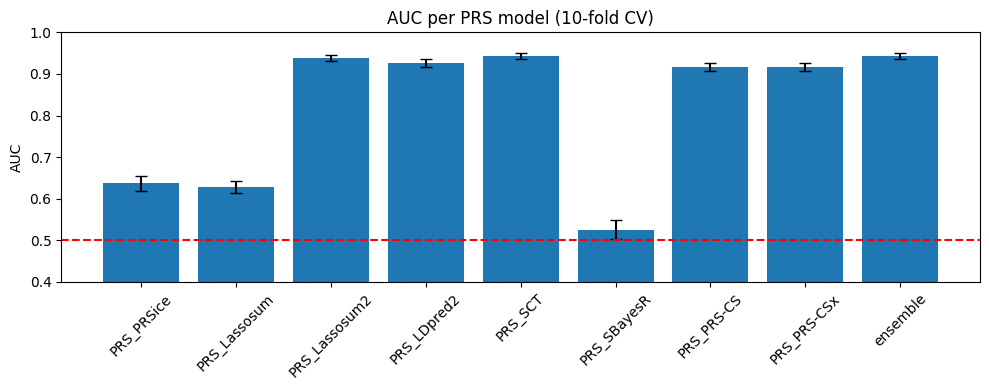

In [110]:
# --- Optional: visualise ---
import matplotlib.pyplot as plt

means = summary.loc['Mean']
stds  = summary.loc['Std']

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(means.index, means.values, yerr=stds.values, capsize=4)
ax.axhline(0.5, color='red', linestyle='--', label='Random')
ax.set_ylabel('AUC')
ax.set_title('AUC per PRS model (10-fold CV)')
ax.set_ylim(0.4, 1.0)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f'plots/prs_lr_auc_{DATA}_updated.png', dpi=150)
plt.show()

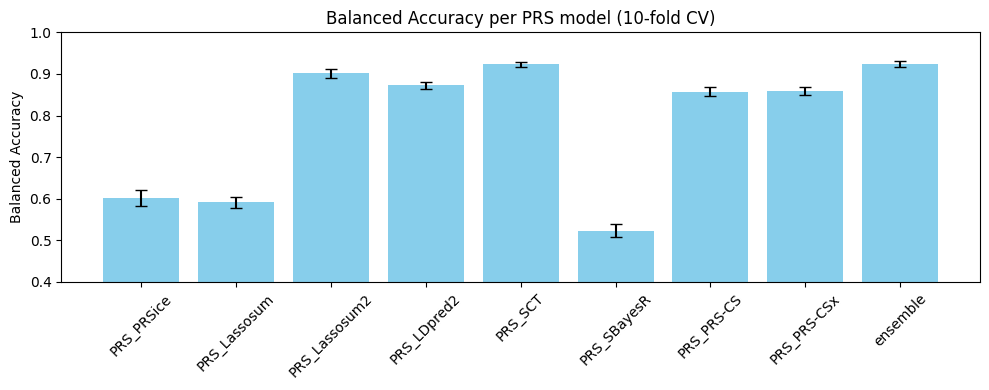

In [111]:
means_accuracy = summary_accuracy.loc['Mean']
stds_accuracy  = summary_accuracy.loc['Std']
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(means_accuracy.index, means_accuracy.values, yerr=stds_accuracy.values,
         capsize=4, color='skyblue')
ax.set_ylabel('Balanced Accuracy')
ax.set_title('Balanced Accuracy per PRS model (10-fold CV)')
ax.set_ylim(0.4, 1.0)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f'plots/prs_lr_balanced_accuracy_{DATA}_updated.png', dpi=150)
plt.show()

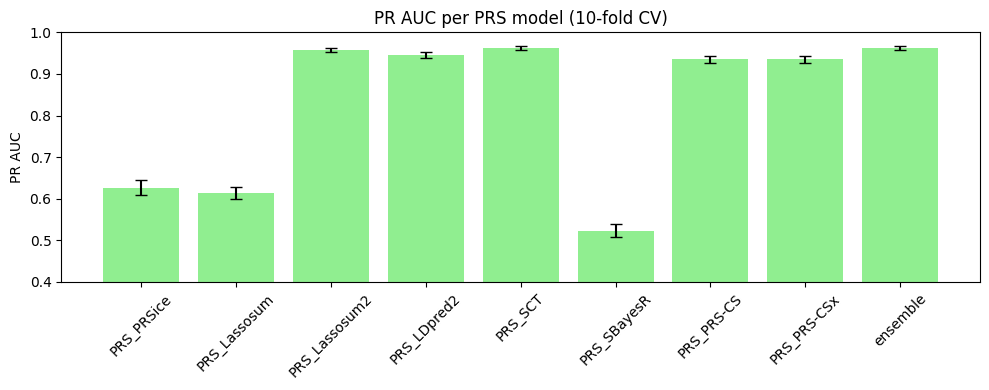

In [112]:
means_pr_auc = summary_pr_auc.loc['Mean']
stds_pr_auc  = summary_pr_auc.loc['Std']
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(means_pr_auc.index, means_pr_auc.values, yerr=stds_pr_auc.values, capsize=4, color='lightgreen')
ax.set_ylabel('PR AUC')
ax.set_title('PR AUC per PRS model (10-fold CV)')
ax.set_ylim(0.4, 1.0)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f'plots/prs_lr_pr_auc_{DATA}_updated.png', dpi=150)
plt.show()